In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

In [2]:
f = pd.read_csv("C:\\Code Note\\FIFA26\\DataCamp Challenge\\WorldCupMatches.csv")


In [3]:
f.shape

(4572, 20)

In [4]:
f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  852 non-null    float64
 1   Datetime              852 non-null    object 
 2   Stage                 852 non-null    object 
 3   Stadium               852 non-null    object 
 4   City                  852 non-null    object 
 5   Home Team Name        852 non-null    object 
 6   Home Team Goals       852 non-null    float64
 7   Away Team Goals       852 non-null    float64
 8   Away Team Name        852 non-null    object 
 9   Win conditions        852 non-null    object 
 10  Attendance            850 non-null    float64
 11  Half-time Home Goals  852 non-null    float64
 12  Half-time Away Goals  852 non-null    float64
 13  Referee               852 non-null    object 
 14  Assistant 1           852 non-null    object 
 15  Assistant 2          

In [5]:
f['Winner'] = f.apply(lambda row: 'home' if row['Home Team Goals'] > row['Away Team Goals'] else ('away' if row['Home Team Goals'] < row['Away Team Goals'] else 'draw'), axis=1)

In [10]:
f[f['Year'] == 1930]

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,...,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials,Winner
0,1930.0,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,...,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX,home
1,1930.0,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,...,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL,home
2,1930.0,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,...,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA,home
3,1930.0,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3.0,1.0,Peru,,...,1.0,0.0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201.0,1098.0,ROU,PER,home
4,1930.0,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1.0,0.0,France,,...,0.0,0.0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201.0,1085.0,ARG,FRA,home
5,1930.0,16 Jul 1930 - 14:45,Group 1,Parque Central,Montevideo,Chile,3.0,0.0,Mexico,,...,1.0,0.0,CRISTOPHE Henry (BEL),APHESTEGUY Martin (URU),LANGENUS Jean (BEL),201.0,1095.0,CHI,MEX,home
6,1930.0,17 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,4.0,0.0,Bolivia,,...,0.0,0.0,MATEUCCI Francisco (URU),LOMBARDI Domingo (URU),WARNKEN Alberto (CHI),201.0,1092.0,YUG,BOL,home
7,1930.0,17 Jul 1930 - 14:45,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Paraguay,,...,2.0,0.0,MACIAS Jose (ARG),APHESTEGUY Martin (URU),TEJADA Anibal (URU),201.0,1097.0,USA,PAR,home
8,1930.0,18 Jul 1930 - 14:30,Group 3,Estadio Centenario,Montevideo,Uruguay,1.0,0.0,Peru,,...,0.0,0.0,LANGENUS Jean (BEL),BALWAY Thomas (FRA),CRISTOPHE Henry (BEL),201.0,1099.0,URU,PER,home
9,1930.0,19 Jul 1930 - 12:50,Group 1,Estadio Centenario,Montevideo,Chile,1.0,0.0,France,,...,0.0,0.0,TEJADA Anibal (URU),LOMBARDI Domingo (URU),REGO Gilberto (BRA),201.0,1094.0,CHI,FRA,home


In [14]:
BG      = "#0a0e1a"
CARD_BG = "#111827"
ACCENT  = "#f59e0b"
WIN_CLR = "#10b981"
LOSE_CLR= "#ef4444"
DRAW_CLR= "#6b7280"
TEXT    = "#f1f5f9"
MUTED   = "#94a3b8"
 
plt.rcParams.update({
    "font.family": "monospace",
    "text.color": TEXT,
    "axes.facecolor": BG,
    "figure.facecolor": BG,
})

In [16]:
f.Stage.unique()

array(['Group 1', 'Group 4', 'Group 2', 'Group 3', 'Semi-finals', 'Final',
       'Preliminary round', 'Quarter-finals', 'Match for third place',
       'First round', 'Group 6', 'Group B', 'Group A', 'Group 5',
       'Group C', 'Group D', 'Group F', 'Group E', 'Round of 16',
       'Group H', 'Group G', 'Third place', 'Play-off for third place',
       nan], dtype=object)

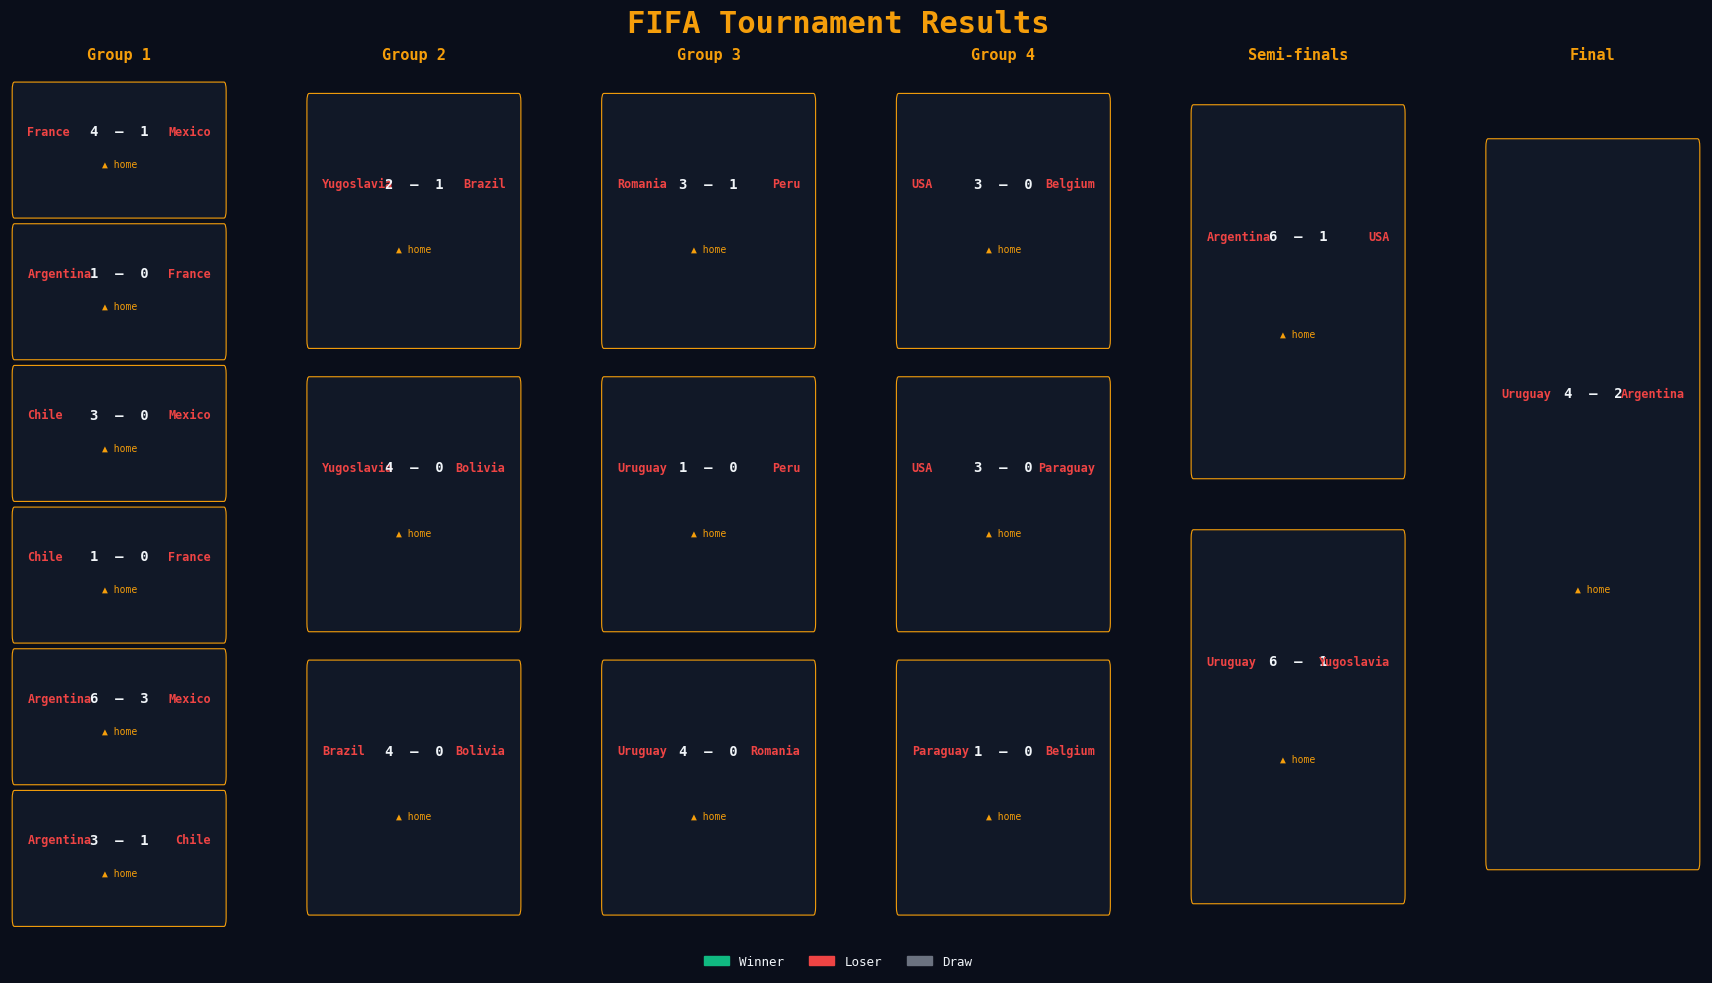

In [21]:
STAGE_ORDER = ["Group 1", "Group 2", "Group 3", "Group 4", "Semi-finals", "Final"
]

stages_in_data = [s for s in STAGE_ORDER if s in f[f['Year'] == 1930]['Stage'].unique()]

fig = plt.figure(figsize=(18, 10), facecolor=BG)
fig.suptitle("FIFA Tournament Results", fontsize=22, fontweight="bold",
             color=ACCENT, y=0.97, fontfamily="monospace")
 
n_stages = len(stages_in_data)
gs = gridspec.GridSpec(1, n_stages, figure=fig, hspace=0.4,
                       left=0.04, right=0.98, top=0.90, bottom=0.05,
                       wspace=0.35)
 
for col_idx, stage in enumerate(stages_in_data):
    stage_df = f[(f["Stage"] == stage) & (f["Year"] == 1930)].reset_index(drop=True)
    ax = fig.add_subplot(gs[0, col_idx])
    ax.set_facecolor(BG)
    ax.axis("off")
 
    # Stage header
    ax.text(0.5, 1.02, stage, ha="center", va="bottom",
            fontsize=11, fontweight="bold", color=ACCENT,
            transform=ax.transAxes)
 
    n = len(stage_df)
    row_h = 1.0 / max(n, 1)
 
    for i, row in stage_df.iterrows():
        home   = row["Home Team Name"]
        away   = row["Away Team Name"]
        hg     = int(row["Home Team Goals"])
        ag     = int(row["Away Team Goals"])
        winner = row["Winner"]
 
        y_top = 1.0 - i * row_h
        y_mid = y_top - row_h / 2
        pad   = row_h * 0.08
 
        # Card background
        card = FancyBboxPatch(
            (0.02, y_top - row_h + pad),
            0.96, row_h - 2 * pad,
            boxstyle="round,pad=0.01",
            linewidth=0.8,
            edgecolor=ACCENT if winner != "Draw" else DRAW_CLR,
            facecolor=CARD_BG,
            transform=ax.transAxes, clip_on=False
        )
        ax.add_patch(card)
 
        # Home team
        home_clr = WIN_CLR if winner == home else (DRAW_CLR if hg == ag else LOSE_CLR)
        ax.text(0.08, y_mid + row_h * 0.13, home,
                ha="left", va="center", fontsize=8.5,
                color=home_clr, fontweight="bold",
                transform=ax.transAxes)
 
        # Score
        score_txt = f"{hg}  –  {ag}"
        ax.text(0.5, y_mid + row_h * 0.13, score_txt,
                ha="center", va="center", fontsize=10,
                color=TEXT, fontweight="bold",
                transform=ax.transAxes)
 
        # Away team
        away_clr = WIN_CLR if winner == away else (DRAW_CLR if hg == ag else LOSE_CLR)
        ax.text(0.92, y_mid + row_h * 0.13, away,
                ha="right", va="center", fontsize=8.5,
                color=away_clr, fontweight="bold",
                transform=ax.transAxes)
 
        # Winner label below
        win_label = f"▲ {winner}" if winner not in ["Draw", None] else "Draw"
        ax.text(0.5, y_mid - row_h * 0.10, win_label,
                ha="center", va="center", fontsize=7,
                color=ACCENT if winner not in ["Draw", None] else DRAW_CLR,
                transform=ax.transAxes)
 
# ── Legend ───────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color=WIN_CLR,  label="Winner"),
    mpatches.Patch(color=LOSE_CLR, label="Loser"),
    mpatches.Patch(color=DRAW_CLR, label="Draw"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=3,
           frameon=False, fontsize=9,
           labelcolor=TEXT, bbox_to_anchor=(0.5, 0.0))

plt.show()

In [42]:
df_ag = f[(f['Home Team Name'] == 'Argentina') | (f['Away Team Name'] == 'Argentina')]

In [43]:
print(f"Total matches between Argentina: {len(df_ag)}")

Total matches between Argentina: 81


In [44]:
Ag = 0
Fr = 0
ag_hm = 0
ag_aw = 0
fr_hm = 0
fr_aw = 0
for idx, row in df_ag_fr.iterrows():
    if row['Home Team Name'] == 'Argentina' and row['Winner'] == 'home':
        Ag += 1
        ag_hm += 1
    elif row['Away Team Name'] == 'Argentina' and row['Winner'] == 'away':
        Ag += 1
        ag_aw += 1
print(f"Argentina wins: {Ag}")
print(f"Argentina home wins: {ag_hm}")
print(f"Argentina away wins: {ag_aw}")

Argentina wins: 41
Argentina home wins: 41
Argentina away wins: 0


In [34]:
HT = f['Home Team Name'].unique()
AT = f['Away Team Name'].unique()

In [46]:
f.dropna(inplace=True)

In [47]:
f

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,...,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials,Winner
0,1930.0,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,...,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX,home
1,1930.0,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,...,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL,home
2,1930.0,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,...,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA,home
3,1930.0,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3.0,1.0,Peru,,...,1.0,0.0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201.0,1098.0,ROU,PER,home
4,1930.0,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1.0,0.0,France,,...,0.0,0.0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201.0,1085.0,ARG,FRA,home
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847,2014.0,05 Jul 2014 - 17:00,Quarter-finals,Arena Fonte Nova,Salvador,Netherlands,0.0,0.0,Costa Rica,Netherlands win on penalties (4 - 3),...,0.0,0.0,Ravshan IRMATOV (UZB),RASULOV Abduxamidullo (UZB),KOCHKAROV Bakhadyr (KGZ),255953.0,300186488.0,NED,CRC,draw
848,2014.0,08 Jul 2014 - 17:00,Semi-finals,Estadio Mineirao,Belo Horizonte,Brazil,1.0,7.0,Germany,,...,0.0,5.0,RODRIGUEZ Marco (MEX),TORRENTERA Marvin (MEX),QUINTERO Marcos (MEX),255955.0,300186474.0,BRA,GER,away
849,2014.0,09 Jul 2014 - 17:00,Semi-finals,Arena de Sao Paulo,Sao Paulo,Netherlands,0.0,0.0,Argentina,Argentina win on penalties (2 - 4),...,0.0,0.0,C�neyt �AKIR (TUR),DURAN Bahattin (TUR),ONGUN Tarik (TUR),255955.0,300186490.0,NED,ARG,draw
850,2014.0,12 Jul 2014 - 17:00,Play-off for third place,Estadio Nacional,Brasilia,Brazil,0.0,3.0,Netherlands,,...,0.0,2.0,HAIMOUDI Djamel (ALG),ACHIK Redouane (MAR),ETCHIALI Abdelhak (ALG),255957.0,300186502.0,BRA,NED,away


In [54]:
for i in range(1930, 2014, 4):
    Teams = f[(f['Year'] == i)]['Stage'].unique()
    print(f"Year: {i}, Teams: {Teams}, len: {len(Teams)}")

Year: 1930, Teams: ['Group 1' 'Group 4' 'Group 2' 'Group 3' 'Semi-finals' 'Final'], len: 6
Year: 1934, Teams: ['Preliminary round' 'Quarter-finals' 'Semi-finals'
 'Match for third place' 'Final'], len: 5
Year: 1938, Teams: ['First round' 'Quarter-finals' 'Semi-finals' 'Match for third place'
 'Final'], len: 5
Year: 1942, Teams: [], len: 0
Year: 1946, Teams: [], len: 0
Year: 1950, Teams: ['Group 1' 'Group 2' 'Group 3' 'Group 4' 'Group 6'], len: 5
Year: 1954, Teams: ['Group 3' 'Group 1' 'Group 2' 'Group 4' 'Quarter-finals' 'Semi-finals'
 'Match for third place' 'Final'], len: 8
Year: 1958, Teams: ['Group 3' 'Group 4' 'Group 1' 'Group 2' 'Quarter-finals' 'Semi-finals'
 'Match for third place' 'Final'], len: 8
Year: 1962, Teams: ['Group 1' 'Group 3' 'Group 4' 'Group 2' 'Quarter-finals' 'Semi-finals'
 'Match for third place' 'Final'], len: 8
Year: 1966, Teams: ['Group 1' 'Group 2' 'Group 3' 'Group 4' 'Quarter-finals' 'Semi-finals'
 'Match for third place' 'Final'], len: 8
Year: 1970, Teams:

In [55]:
f[f['Year'] == 1950]

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,...,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials,Winner
53,1950.0,24 Jun 1950 - 15:00,Group 1,Maracan� - Est�dio Jornalista M�rio Filho,Rio De Janeiro,Brazil,4.0,0.0,Mexico,,...,1.0,0.0,READER George (ENG),GRIFFITHS Benjamin (WAL),MITCHELL George (SCO),208.0,1187.0,BRA,MEX,home
54,1950.0,25 Jun 1950 - 15:00,Group 2,Maracan� - Est�dio Jornalista M�rio Filho,Rio De Janeiro,England,2.0,0.0,Chile,,...,1.0,0.0,VAN DER MEER Karel (NED),GARDELLI Mario (BRA),DAHLNER Gunnar (SWE),208.0,1192.0,ENG,CHI,home
55,1950.0,25 Jun 1950 - 15:00,Group 2,Durival de Brito,Curitiba,Spain,3.0,1.0,USA,,...,0.0,1.0,VIANA Mario (BRA),DA COSTA VIEIRA Jose (POR),DE LA SALLE Charles (FRA),208.0,1208.0,ESP,USA,home
56,1950.0,25 Jun 1950 - 15:00,Group 3,Pacaembu,Sao Paulo,Sweden,3.0,2.0,Italy,,...,2.0,1.0,LUTZ Jean (SUI),BERANEK Alois (AUT),TEJADA Carlos (MEX),208.0,1219.0,SWE,ITA,home
57,1950.0,25 Jun 1950 - 15:00,Group 1,Independencia,Belo Horizonte,Yugoslavia,3.0,0.0,Switzerland,,...,0.0,0.0,GALEATI Giovanni (ITA),EKLIND Ivan (SWE),DATTILO Generoso (ITA),208.0,1230.0,YUG,SUI,home
58,1950.0,28 Jun 1950 - 15:00,Group 1,Pacaembu,Sao Paulo,Brazil,2.0,2.0,Switzerland,,...,2.0,1.0,AZON ROMA Ramon (ESP),BUSTAMANTE Sergio (CHI),DE NICOLA Cayetano (PAR),208.0,1188.0,BRA,SUI,draw
59,1950.0,28 Jun 1950 - 15:00,Group 1,Eucaliptos,Porto Alegre,Yugoslavia,4.0,1.0,Mexico,,...,2.0,0.0,LEAFE Reginald (ENG),DAHLNER Gunnar (SWE),VAN DER MEER Karel (NED),208.0,1225.0,YUG,MEX,home
60,1950.0,29 Jun 1950 - 15:00,Group 2,Maracan� - Est�dio Jornalista M�rio Filho,Rio De Janeiro,Spain,2.0,0.0,Chile,,...,2.0,0.0,MALCHER Alberto (BRA),MARINO Esteban (URU),ALVAREZ Alfredo (BOL),208.0,1193.0,ESP,CHI,home
61,1950.0,29 Jun 1950 - 15:30,Group 3,Durival de Brito,Curitiba,Sweden,2.0,2.0,Paraguay,,...,2.0,1.0,MITCHELL Robert (SCO),LEMESIC Leo (YUG),GARCIA Prudencio (USA),208.0,1228.0,SWE,PAR,draw
62,1950.0,29 Jun 1950 - 15:00,Group 2,Independencia,Belo Horizonte,USA,1.0,0.0,England,,...,1.0,0.0,DATTILO Generoso (ITA),DE LA SALLE Charles (FRA),GALEATI Giovanni (ITA),208.0,1202.0,USA,ENG,home


In [57]:
f.columns

Index(['Year', 'Datetime', 'Stage', 'Stadium', 'City', 'Home Team Name',
       'Home Team Goals', 'Away Team Goals', 'Away Team Name',
       'Win conditions', 'Attendance', 'Half-time Home Goals',
       'Half-time Away Goals', 'Referee', 'Assistant 1', 'Assistant 2',
       'RoundID', 'MatchID', 'Home Team Initials', 'Away Team Initials',
       'Winner'],
      dtype='object')